# importing libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from sklearn.metrics import confusion_matrix, classification_report
import time
import itertools
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, optimizers, Sequential

# loading the fashion-MINST dataset

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist
from matplotlib import pyplot as plt
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
# Normalizing
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatting to vector
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

num_classes = 10

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# explaining the hyper parameters
- they are configuration settings for a nerual network
- they are not trained during the process
- learning rate: the step size at each iteration while moving toward a minimum of the loss function.
  - a smaller learning rate can lead to more accurate minimum but convergance needs more time
  - large learing rate is faster but has more error
- nerons number in each layer: the more neruns the more complex patterns the model can learn but using too much may lead to overfitting like training on noise. fewer numbers in neurons helps the model to be more generalized but may have less accuracy
- number of hidden layers: adding more layers increases the computational effort but the model learns on a higher level of complexity
- batch size: it is the number of samples the model processes before it is updated.  Smaller batch sizes can offer a regularizing effect but may lead to noisy gradients.
- activation function: function applied to the output of each node in a layer. like ReLU, sigmoid, tanh ....
- optimizer: the method used to update the weights like Adam, RMSprop ....
- regularization parameter: methods like dropout or L2 regularization which prevents overfitting


# creating model with variable hyper parameters

In [ ]:
def create_model(hidden_layers=[128], num_classes=10, learning_rate=0.001):
    model = Sequential()
    for nodes in hidden_layers:
        model.add(layers.Dense(nodes, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Using four hidden layers 128, 64, 32, 16 nodes , learning rate 0.01

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6359 - loss: 0.9795 - val_accuracy: 0.8275 - val_loss: 0.5171
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8414 - loss: 0.4490 - val_accuracy: 0.8382 - val_loss: 0.4476
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8587 - loss: 0.3966 - val_accuracy: 0.8558 - val_loss: 0.4076
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8680 - loss: 0.3651 - val_accuracy: 0.8612 - val_loss: 0.3909
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8748 - loss: 0.3471 - val_accuracy: 0.8741 - val_loss: 0.3592
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8819 - loss: 0.3319 - val_accuracy: 0.8634 - val_loss: 0.3790
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8806 - loss: 0.3283 - val_accuracy: 0.8695 - val_loss: 0.3735
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8850 - loss: 0.3195 - val_accuracy: 0.

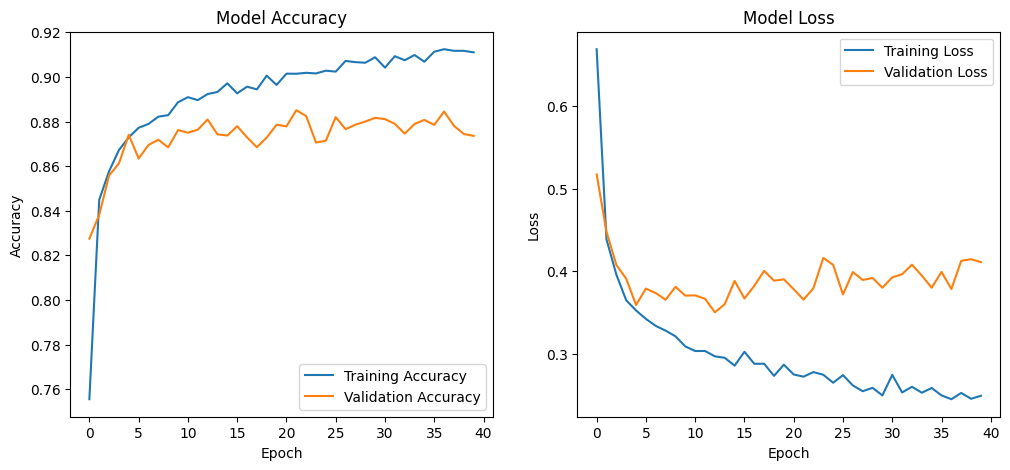

Test Accuracy: 86.81%
Test Loss: 0.4369


In [ ]:
hidden_layers = [128, 64, 32, 16]
learning_rate = 0.01
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=40, batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# Four hidden layer 128,64,32,16 nodes learning rate 0.001

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6317 - loss: 1.0348 - val_accuracy: 0.8272 - val_loss: 0.4933
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8502 - loss: 0.4290 - val_accuracy: 0.8531 - val_loss: 0.4189
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8657 - loss: 0.3709 - val_accuracy: 0.8643 - val_loss: 0.3813
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8763 - loss: 0.3437 - val_accuracy: 0.8742 - val_loss: 0.3497
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8815 - loss: 0.3250 - val_accuracy: 0.8799 - val_loss: 0.3398
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8882 - loss: 0.3022 - val_accuracy: 0.8655 - val_loss: 0.3668
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8897 - loss: 0.2950 - val_accuracy: 0.8737 - val_loss: 0.3423
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8948 - loss: 0.2822 - val_accuracy: 0.

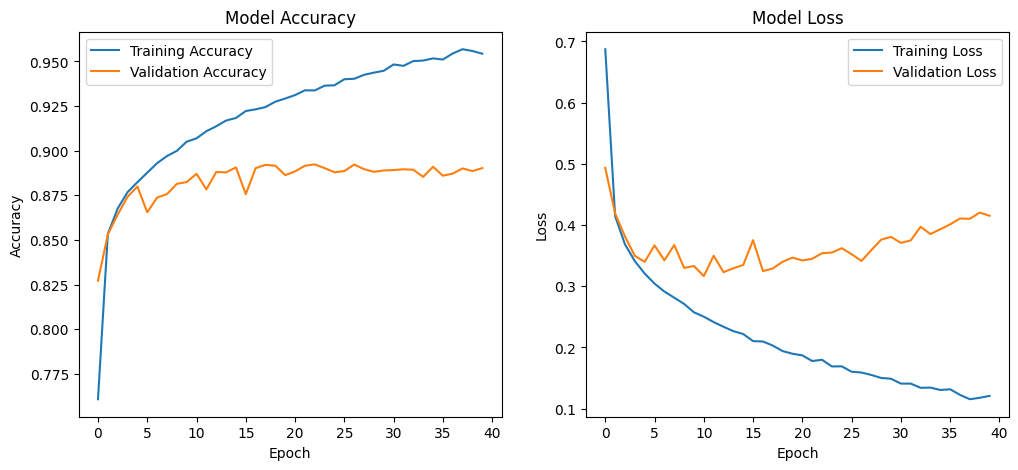

Test Accuracy: 88.28%
Test Loss: 0.4749


In [ ]:
hidden_layers = [128, 64, 32, 16]
learning_rate = 0.001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=40, batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# four hidden layers 64,32,32,16 nodes learning rate 0.001

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6160 - loss: 1.0867 - val_accuracy: 0.8256 - val_loss: 0.4969
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8393 - loss: 0.4606 - val_accuracy: 0.8461 - val_loss: 0.4350
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8572 - loss: 0.4046 - val_accuracy: 0.8631 - val_loss: 0.3873
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8665 - loss: 0.3741 - val_accuracy: 0.8648 - val_loss: 0.3875
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8758 - loss: 0.3478 - val_accuracy: 0.8724 - val_loss: 0.3600
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8831 - loss: 0.3256 - val_accuracy: 0.8717 - val_loss: 0.3691
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8852 - loss: 0.3168 - val_accuracy: 0.8794 - val_loss: 0.3418
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8895 - loss: 0.3070 - val_accuracy: 0.

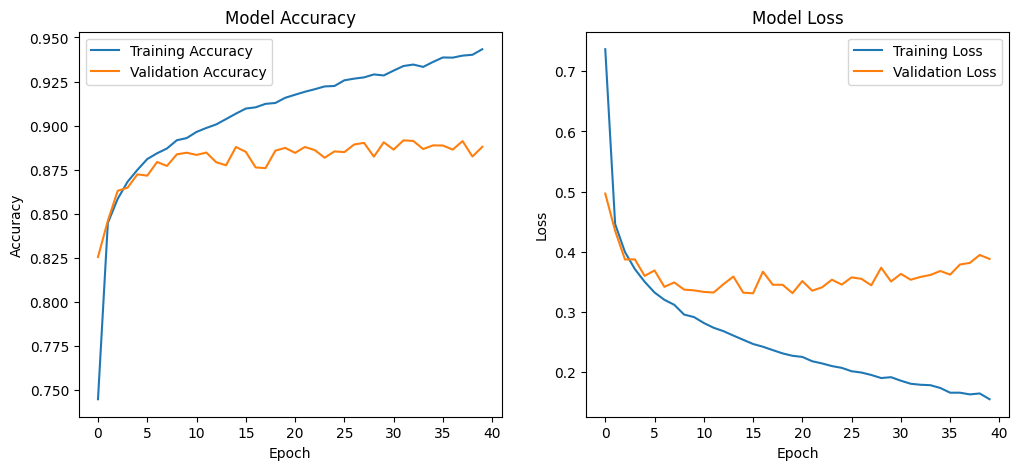

Test Accuracy: 88.47%
Test Loss: 0.4215


In [ ]:
hidden_layers = [64, 32, 32, 16]
learning_rate = 0.001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=40, batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# four hidden layer with 32,32,16,16 nodes learning rate 0.001

Epoch 1/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5839 - loss: 1.2107 - val_accuracy: 0.8260 - val_loss: 0.4964
Epoch 2/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8330 - loss: 0.4825 - val_accuracy: 0.8449 - val_loss: 0.4417
Epoch 3/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8529 - loss: 0.4240 - val_accuracy: 0.8562 - val_loss: 0.4149
Epoch 4/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8579 - loss: 0.4001 - val_accuracy: 0.8558 - val_loss: 0.4169
Epoch 5/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8649 - loss: 0.3798 - val_accuracy: 0.8567 - val_loss: 0.4135
Epoch 6/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8691 - loss: 0.3670 - val_accuracy: 0.8555 - val_loss: 0.4248
Epoch 7/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8738 - loss: 0.3538 - val_accuracy: 0.8586 - val_loss: 0.4037
Epoch 8/80
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8761 - loss: 0.3435 - val_accuracy: 0.

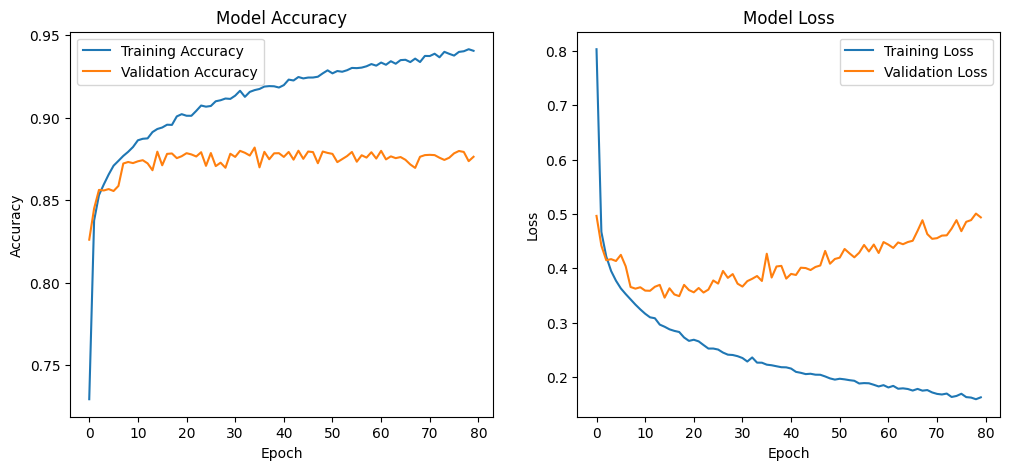

Test Accuracy: 87.09%
Test Loss: 0.5223


In [ ]:
hidden_layers = [32, 32, 16, 16]
learning_rate = 0.001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=80, batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# four hidden layer 32,32,16,16 nodes and learning rate 0.0001 but 100 epochs

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2783 - loss: 2.0239 - val_accuracy: 0.6039 - val_loss: 1.2738
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6262 - loss: 1.1761 - val_accuracy: 0.7393 - val_loss: 0.8744
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7567 - loss: 0.8069 - val_accuracy: 0.7920 - val_loss: 0.6463
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8015 - loss: 0.6220 - val_accuracy: 0.8074 - val_loss: 0.5731
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8142 - loss: 0.5625 - val_accuracy: 0.8162 - val_loss: 0.5397
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8242 - loss: 0.5249 - val_accuracy: 0.8252 - val_loss: 0.5130
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8324 - loss: 0.4964 - val_accuracy: 0.8266 - val_loss: 0.4989
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8355 - loss: 0.4805 - val_accu

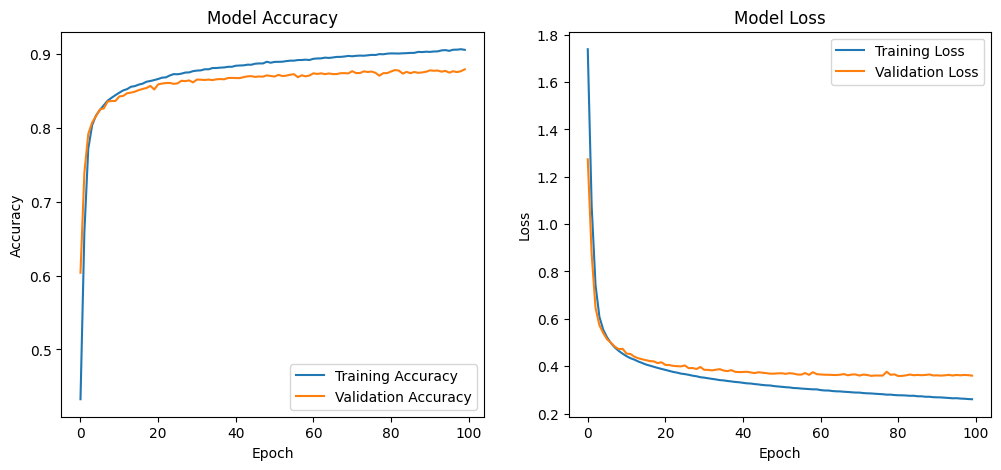

Test Accuracy: 86.87%
Test Loss: 0.3781


In [ ]:
hidden_layers = [32, 32, 16, 16]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=100 , batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# four hidden layer with 32 16 16 8 nodes and learing rate 0.01 and 100 epochs

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5897 - loss: 1.0914 - val_accuracy: 0.8258 - val_loss: 0.4953
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8266 - loss: 0.4838 - val_accuracy: 0.8438 - val_loss: 0.4468
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8425 - loss: 0.4419 - val_accuracy: 0.8497 - val_loss: 0.4288
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8588 - loss: 0.3983 - val_accuracy: 0.8568 - val_loss: 0.4131
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8579 - loss: 0.3924 - val_accuracy: 0.8607 - val_loss: 0.4187
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8645 - loss: 0.3761 - val_accuracy: 0.8571 - val_loss: 0.4115
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8701 - loss: 0.3663 - val_accuracy: 0.8459 - val_loss: 0.4470
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8706 - loss: 0.3579 - val_accu

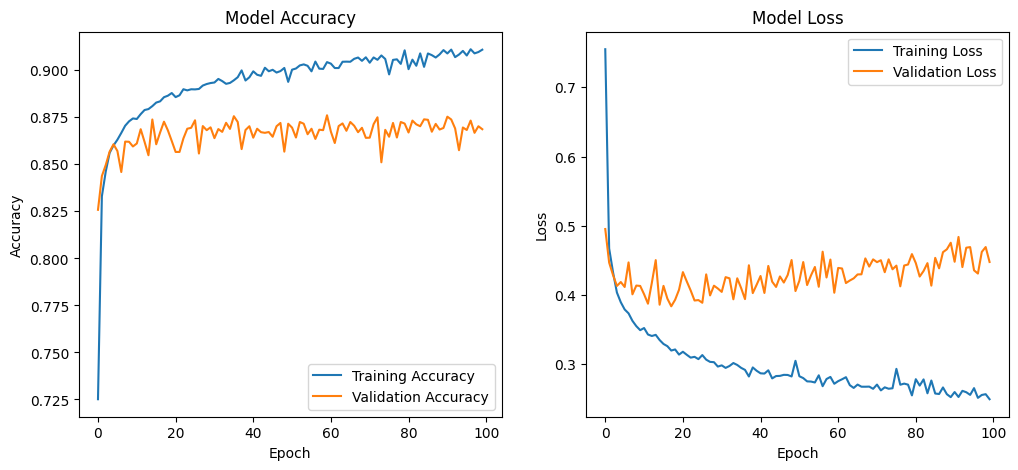

Test Accuracy: 85.99%
Test Loss: 0.4740


In [ ]:
hidden_layers = [32, 16, 16, 8]
learning_rate = 0.01
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# Using three hidden layers with 128, 64, 32 nodes learning rate 0.01

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6852 - loss: 0.8836 - val_accuracy: 0.8313 - val_loss: 0.4718
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8413 - loss: 0.4355 - val_accuracy: 0.8392 - val_loss: 0.4339
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8575 - loss: 0.3870 - val_accuracy: 0.8568 - val_loss: 0.3996
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8665 - loss: 0.3617 - val_accuracy: 0.8690 - val_loss: 0.3848
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8703 - loss: 0.3511 - val_accuracy: 0.8643 - val_loss: 0.3812
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8772 - loss: 0.3376 - val_accuracy: 0.8561 - val_loss: 0.3946
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8805 - loss: 0.3288 - val_accuracy: 0.8732 - val_loss: 0.3569
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8872 - loss: 0.3081 - val_accuracy: 

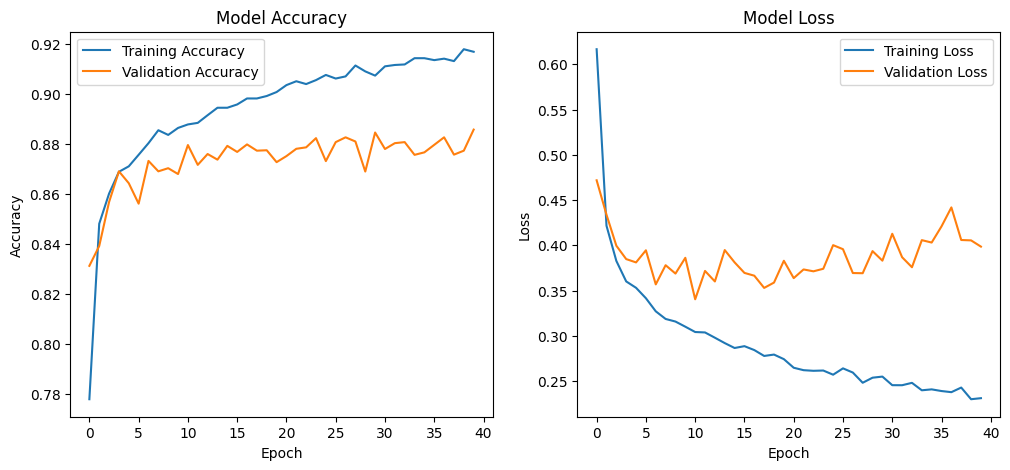

Test Accuracy: 87.64%
Test Loss: 0.4216


In [ ]:
hidden_layers = [128, 64, 32]
learning_rate = 0.01
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=40, batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# three hidden layers 64, 32, 16 learnign rate 0.001

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6280 - loss: 1.0675 - val_accuracy: 0.8269 - val_loss: 0.4906
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8428 - loss: 0.4482 - val_accuracy: 0.8514 - val_loss: 0.4307
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8587 - loss: 0.4026 - val_accuracy: 0.8612 - val_loss: 0.3950
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8682 - loss: 0.3785 - val_accuracy: 0.8620 - val_loss: 0.3856
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8774 - loss: 0.3495 - val_accuracy: 0.8651 - val_loss: 0.3813
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8806 - loss: 0.3340 - val_accuracy: 0.8735 - val_loss: 0.3540
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8833 - loss: 0.3227 - val_accuracy: 0.8742 - val_loss: 0.3526
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8839 - loss: 0.3187 - val_accuracy: 0.

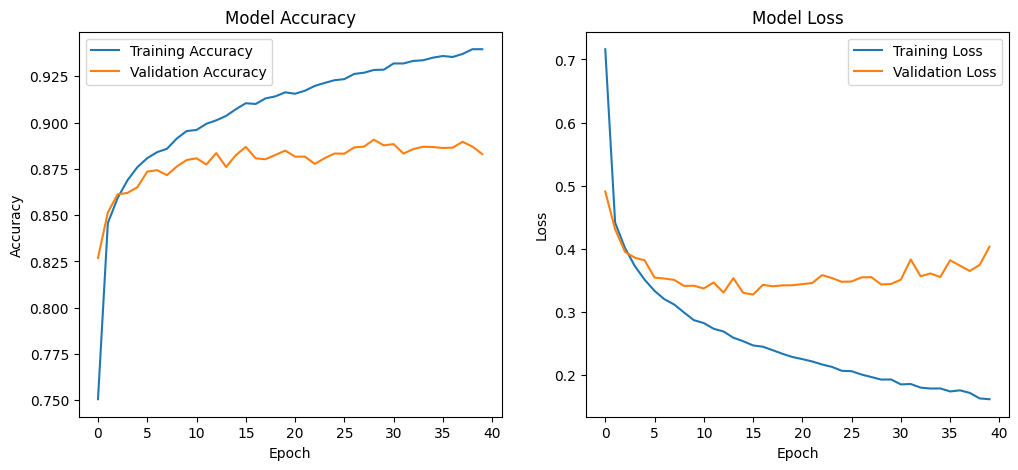

Test Accuracy: 87.20%
Test Loss: 0.4518


In [ ]:
hidden_layers = [64, 32, 16]
learning_rate = 0.001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=40, batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# three hidden layers 32,16,8 nodes learning rate 0.001

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4271 - loss: 1.6734 - val_accuracy: 0.7418 - val_loss: 0.8668
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7539 - loss: 0.7918 - val_accuracy: 0.7619 - val_loss: 0.6162
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7966 - loss: 0.5509 - val_accuracy: 0.8290 - val_loss: 0.4953
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8393 - loss: 0.4733 - val_accuracy: 0.8428 - val_loss: 0.4635
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8488 - loss: 0.4286 - val_accuracy: 0.8503 - val_loss: 0.4374
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8639 - loss: 0.3998 - val_accuracy: 0.8608 - val_loss: 0.4153
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8668 - loss: 0.3833 - val_accuracy: 0.8567 - val_loss: 0.4245
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8693 - loss: 0.3673 - val_accuracy: 0.

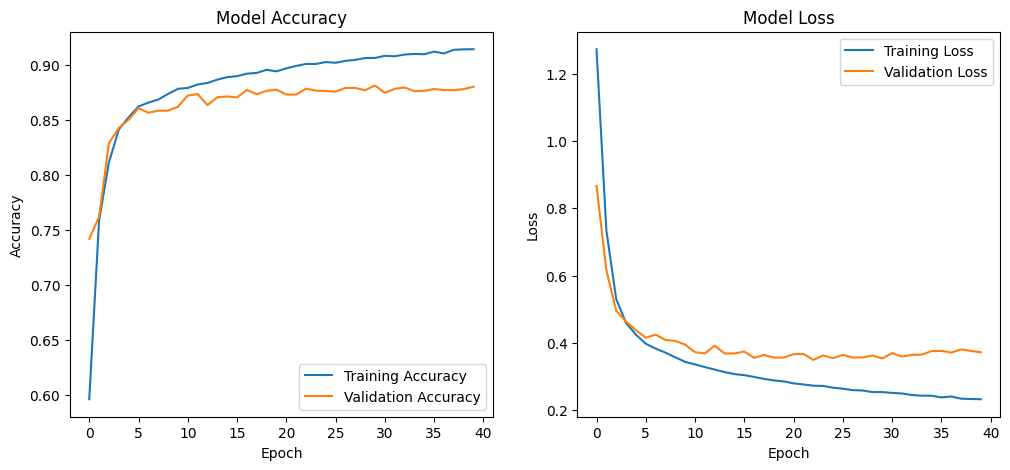

Test Accuracy: 87.00%
Test Loss: 0.4047


In [ ]:
hidden_layers = [32, 16, 8]
learning_rate = 0.001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=40, batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# three hidden layers 16,16,8 nodes and learninf rate 0.0001 with 100 epochs

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3027 - loss: 2.0840 - val_accuracy: 0.5701 - val_loss: 1.4529
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5994 - loss: 1.3232 - val_accuracy: 0.6758 - val_loss: 0.9979
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6938 - loss: 0.9417 - val_accuracy: 0.7376 - val_loss: 0.7936
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7468 - loss: 0.7707 - val_accuracy: 0.7642 - val_loss: 0.6959
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7703 - loss: 0.6842 - val_accuracy: 0.7837 - val_loss: 0.6430
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7858 - loss: 0.6362 - val_accuracy: 0.7987 - val_loss: 0.6013
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8039 - loss: 0.5875 - val_accuracy: 0.8069 - val_loss: 0.5755
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8074 - loss: 0.5750 - val_accu

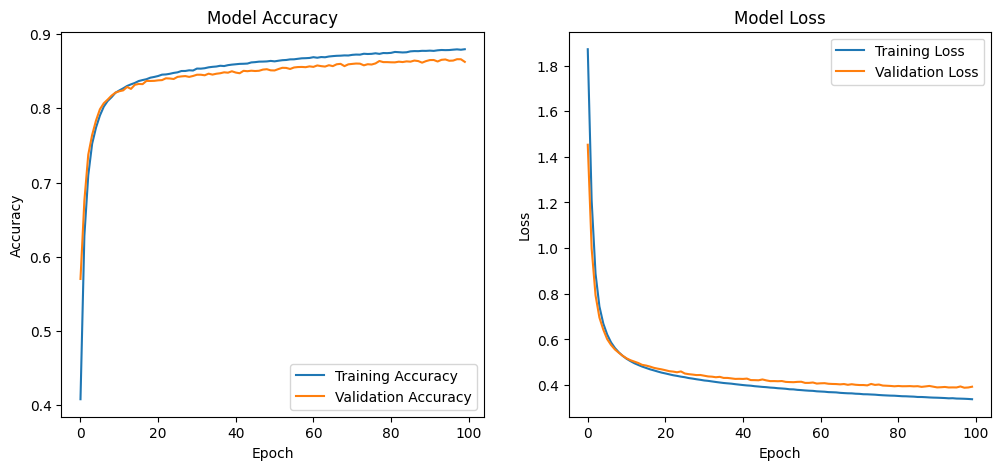

Test Accuracy: 85.21%
Test Loss: 0.4208


In [ ]:
hidden_layers = [16, 16, 8]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# Training
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_split=0.2)

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# three hidden layers with 20,8,4 and adaptive learning rate for 120  epochs

Epoch 1/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4860 - loss: 1.2703 - val_accuracy: 0.7354 - val_loss: 0.6745 - learning_rate: 0.0100
Epoch 2/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7378 - loss: 0.6465 - val_accuracy: 0.8042 - val_loss: 0.5538 - learning_rate: 0.0100
Epoch 3/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8033 - loss: 0.5416 - val_accuracy: 0.7851 - val_loss: 0.5999 - learning_rate: 0.0100
Epoch 4/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8216 - loss: 0.5160 - val_accuracy: 0.8223 - val_loss: 0.5173 - learning_rate: 0.0100
Epoch 5/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8328 - loss: 0.4860 - val_accuracy: 0.8413 - val_loss: 0.4823 - learning_rate: 0.0100
Epoch 6/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8425 - loss: 0.4668 - val_accuracy: 0.8360 - val_loss: 0.4666 - learning_rate: 0.0100
Epoch 7/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8

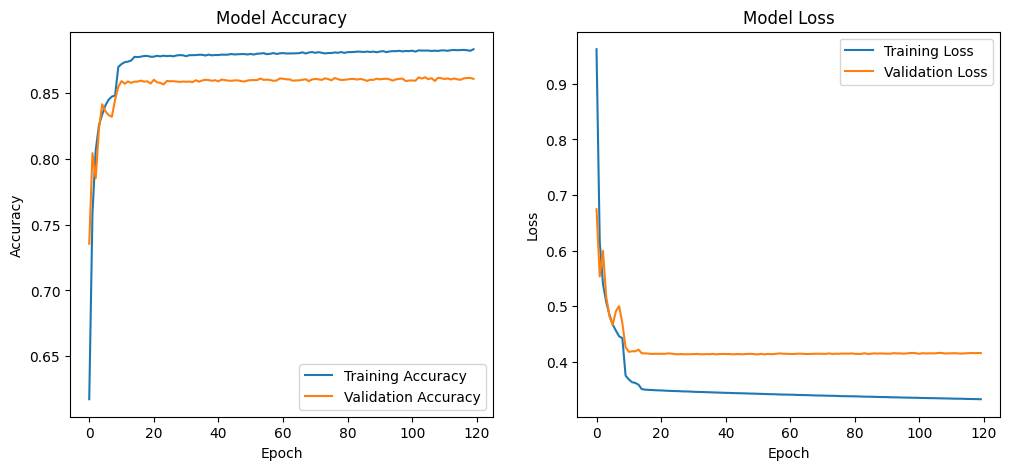

Test Accuracy: 85.02%
Test Loss: 0.4459


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

initial_learning_rate = 0.01
model = create_model(hidden_layers=[20, 8, 4], num_classes=10, learning_rate=initial_learning_rate)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.1, patience=3, min_lr=0.0001, verbose=1)
history = model.fit(X_train, y_train,epochs=120, batch_size=32, validation_split=0.2, callbacks=[reduce_lr])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# three hidden layers 20,20,20 with adaptive learning rate

Epoch 1/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6985 - loss: 0.8158 - val_accuracy: 0.8216 - val_loss: 0.5106 - learning_rate: 0.0100
Epoch 2/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8109 - loss: 0.5294 - val_accuracy: 0.8105 - val_loss: 0.5283 - learning_rate: 0.0100
Epoch 3/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8225 - loss: 0.4969 - val_accuracy: 0.8313 - val_loss: 0.4681 - learning_rate: 0.0100
Epoch 4/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8232 - loss: 0.4921 - val_accuracy: 0.8260 - val_loss: 0.4913 - learning_rate: 0.0100
Epoch 5/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8331 - loss: 0.4741 - val_accuracy: 0.8347 - val_loss: 0.4674 - learning_rate: 0.0100
Epoch 6/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8349 - loss: 0.4668 - val_accuracy: 0.8336 - val_loss: 0.4862 - learning_rate: 0.0100
Epoch 7/120
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8

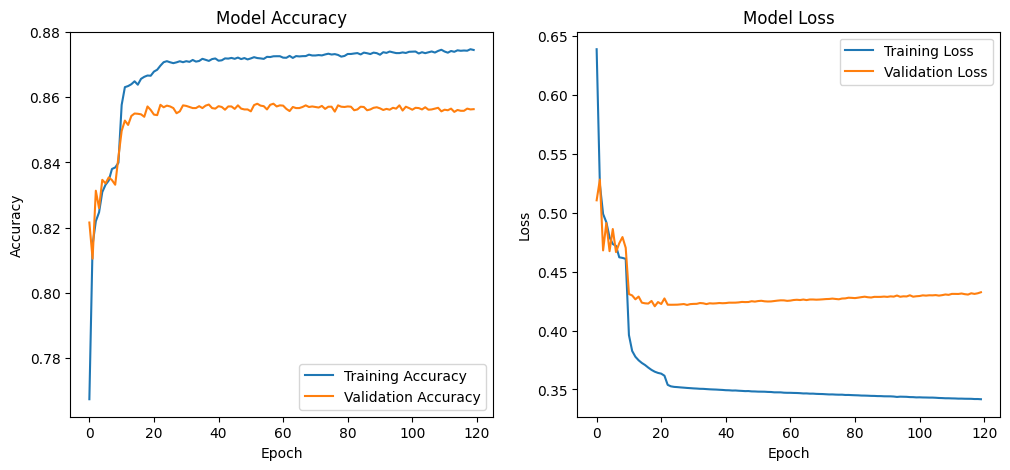

Test Accuracy: 84.69%
Test Loss: 0.4551


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

initial_learning_rate = 0.01
model = create_model(hidden_layers=[20, 20, 20], num_classes=10, learning_rate=initial_learning_rate)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.1, patience=3, min_lr=0.0001, verbose=1)
history = model.fit(X_train, y_train,epochs=120, batch_size=32, validation_split=0.2, callbacks=[reduce_lr])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluating the model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# two hidden layers with 32, 16 learning rate 0.01 and using early stopping

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7001 - loss: 0.8359 - val_accuracy: 0.8434 - val_loss: 0.4468
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8524 - loss: 0.4188 - val_accuracy: 0.8511 - val_loss: 0.4087
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8584 - loss: 0.3913 - val_accuracy: 0.8472 - val_loss: 0.4157
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8618 - loss: 0.3734 - val_accuracy: 0.8575 - val_loss: 0.3963
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8696 - loss: 0.3573 - val_accuracy: 0.8648 - val_loss: 0.3788
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8695 - loss: 0.3601 - val_accuracy: 0.8676 - val_loss: 0.3705
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8757 - loss: 0.3360 - val_accuracy: 0.8681 - val_loss: 0.3840
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8757 - loss: 0.3406 - val_accu

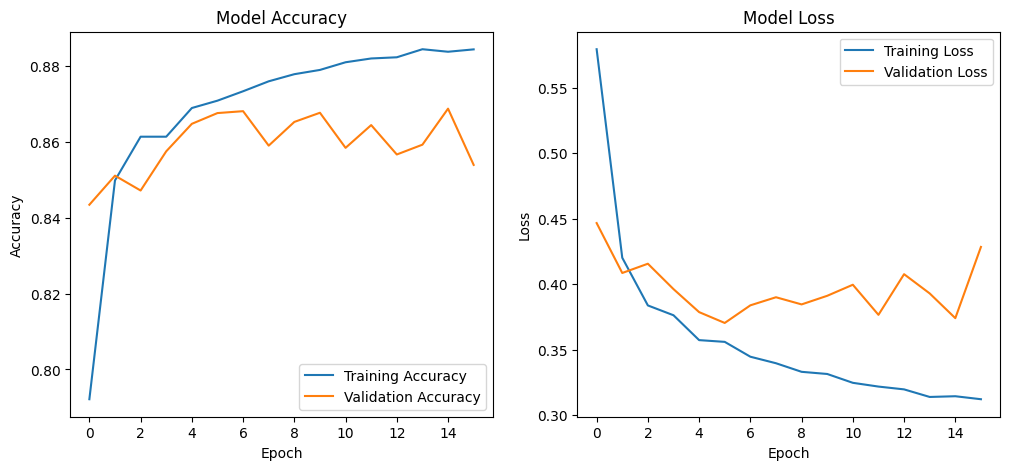

Test Accuracy: 86.03%
Test Loss: 0.3972


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [32, 16]
learning_rate = 0.01
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# two hidden layers with 32, 16 nodes and learning rate 0.001

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6112 - loss: 1.1393 - val_accuracy: 0.8295 - val_loss: 0.5024
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8376 - loss: 0.4773 - val_accuracy: 0.8482 - val_loss: 0.4393
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8523 - loss: 0.4202 - val_accuracy: 0.8542 - val_loss: 0.4246
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8604 - loss: 0.3981 - val_accuracy: 0.8455 - val_loss: 0.4325
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8690 - loss: 0.3746 - val_accuracy: 0.8616 - val_loss: 0.3950
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8738 - loss: 0.3584 - val_accuracy: 0.8644 - val_loss: 0.3849
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8741 - loss: 0.3545 - val_accuracy: 0.8662 - val_loss: 0.3759
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8755 - loss: 0.3455 - val_accu

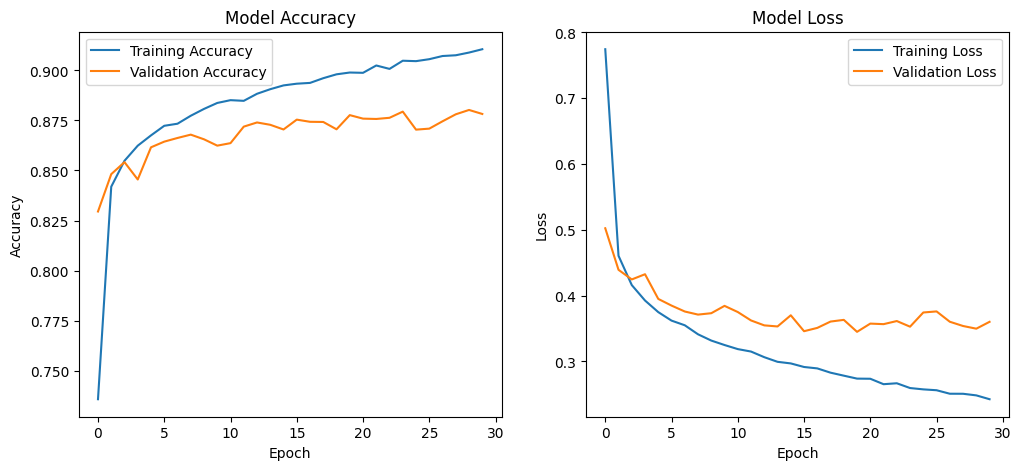

Test Accuracy: 87.11%
Test Loss: 0.3686


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [32, 16]
learning_rate = 0.001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# two hidden layer with 32,16 nodes and 0.0001 learning rate


Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3952 - loss: 1.7753 - val_accuracy: 0.6955 - val_loss: 0.9205
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7085 - loss: 0.8581 - val_accuracy: 0.7604 - val_loss: 0.7165
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7648 - loss: 0.6984 - val_accuracy: 0.7855 - val_loss: 0.6312
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7896 - loss: 0.6212 - val_accuracy: 0.8055 - val_loss: 0.5790
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8058 - loss: 0.5696 - val_accuracy: 0.8158 - val_loss: 0.5446
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8180 - loss: 0.5344 - val_accuracy: 0.8248 - val_loss: 0.5197
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8266 - loss: 0.5135 - val_accuracy: 0.8311 - val_loss: 0.5007
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8340 - loss: 0.4948 - val_accu

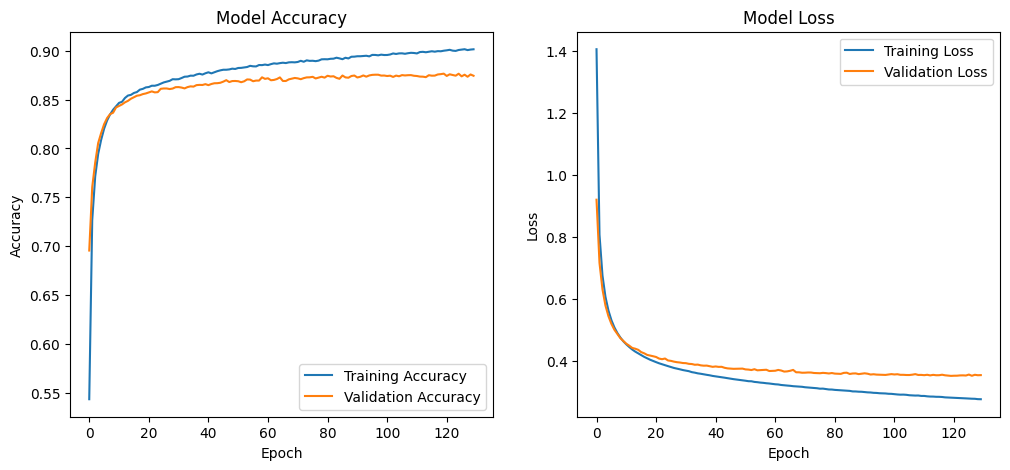

Test Accuracy: 86.81%
Test Loss: 0.3781


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [32, 16]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=200, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# two hidden layer with 16,16 nodes and 0.0001 learning rate


Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3251 - loss: 1.9098 - val_accuracy: 0.6128 - val_loss: 1.2007
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6372 - loss: 1.1107 - val_accuracy: 0.6984 - val_loss: 0.9002
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7067 - loss: 0.8641 - val_accuracy: 0.7416 - val_loss: 0.7670
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7498 - loss: 0.7494 - val_accuracy: 0.7697 - val_loss: 0.6847
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7778 - loss: 0.6715 - val_accuracy: 0.7922 - val_loss: 0.6298
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7951 - loss: 0.6243 - val_accuracy: 0.8002 - val_loss: 0.5910
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8081 - loss: 0.5837 - val_accuracy: 0.8093 - val_loss: 0.5604
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8146 - loss: 0.5489 - val_accu

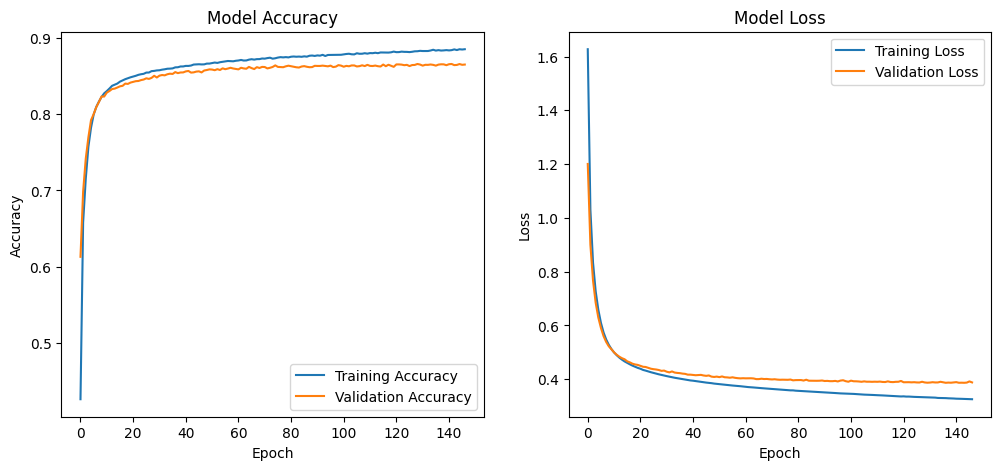

Test Accuracy: 85.93%
Test Loss: 0.4149


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [16, 16]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=200, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# two hidden layers 16, 8 nodes and 0.0001 learning rate

Epoch 1/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0749 - loss: 2.1793 - val_accuracy: 0.3033 - val_loss: 1.7819
Epoch 2/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3910 - loss: 1.6923 - val_accuracy: 0.5671 - val_loss: 1.4530
Epoch 3/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5784 - loss: 1.4109 - val_accuracy: 0.6062 - val_loss: 1.2606
Epoch 4/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6300 - loss: 1.2193 - val_accuracy: 0.6672 - val_loss: 1.1129
Epoch 5/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6757 - loss: 1.0847 - val_accuracy: 0.6787 - val_loss: 0.9907
Epoch 6/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6884 - loss: 0.9652 - val_accuracy: 0.6877 - val_loss: 0.9035
Epoch 7/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6937 - loss: 0.8831 - val_accuracy: 0.7207 - val_loss: 0.8233
Epoch 8/200
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7372 - loss: 0.8014 - val_accu

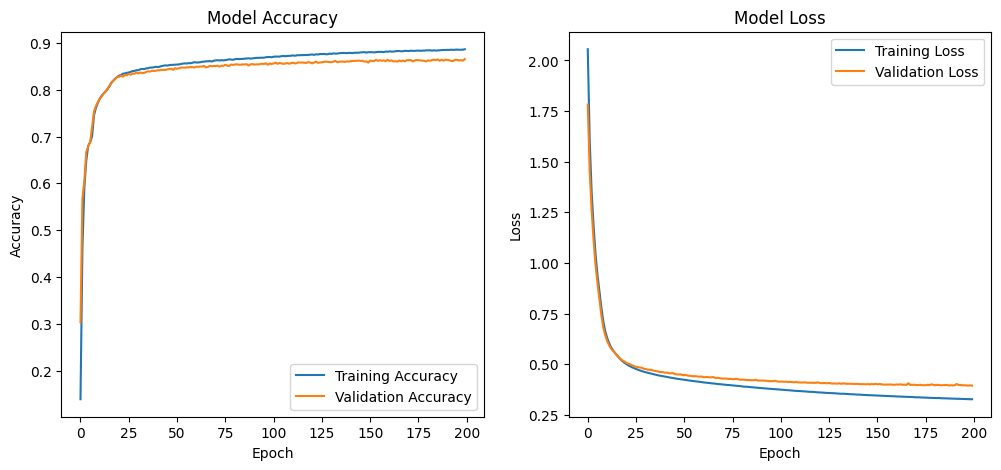

Test Accuracy: 85.60%
Test Loss: 0.4228


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [16, 8]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=200, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# two hidden layers with 8,8 nodes and learning rate 0.0001

Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2564 - loss: 2.1552 - val_accuracy: 0.3531 - val_loss: 1.8663
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4258 - loss: 1.7635 - val_accuracy: 0.5412 - val_loss: 1.4854
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5427 - loss: 1.4482 - val_accuracy: 0.5646 - val_loss: 1.2879
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5635 - loss: 1.2662 - val_accuracy: 0.5902 - val_loss: 1.1656
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5853 - loss: 1.1550 - val_accuracy: 0.6061 - val_loss: 1.0707
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6003 - loss: 1.0716 - val_accuracy: 0.6256 - val_loss: 0.9876
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6271 - loss: 0.9882 - val_accuracy: 0.6676 - val_loss: 0.9090
Epoch 8/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6730 - loss: 0.9020 - val_accu

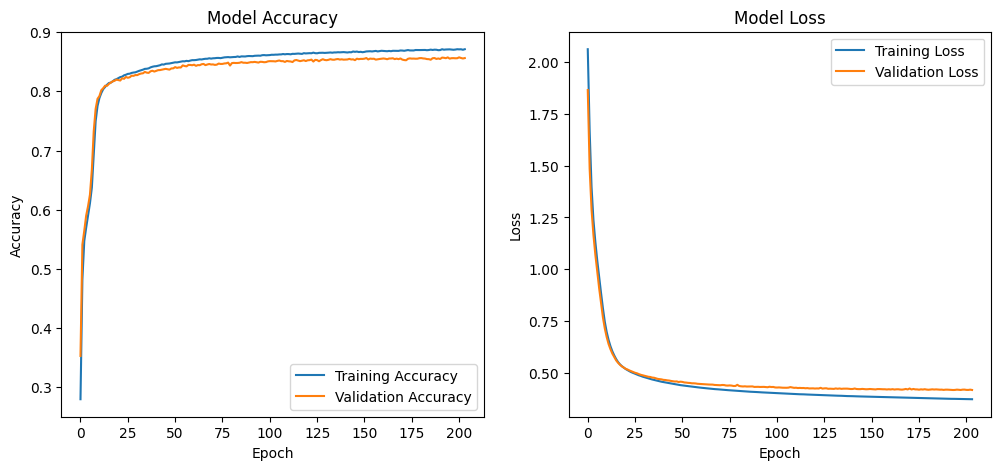

Test Accuracy: 84.22%
Test Loss: 0.4422


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [8, 8]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# using one hidden layer with 128 nodes and 0.0001 learning rate with early stopping


Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5975 - loss: 1.3400 - val_accuracy: 0.7879 - val_loss: 0.6531
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8035 - loss: 0.6128 - val_accuracy: 0.8187 - val_loss: 0.5495
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8226 - loss: 0.5377 - val_accuracy: 0.8287 - val_loss: 0.5057
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8359 - loss: 0.4958 - val_accuracy: 0.8295 - val_loss: 0.4876
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8449 - loss: 0.4624 - val_accuracy: 0.8412 - val_loss: 0.4591
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8486 - loss: 0.4449 - val_accuracy: 0.8465 - val_loss: 0.4458
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8536 - loss: 0.4349 - val_accuracy: 0.8467 - val_loss: 0.4402
Epoch 8/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8567 - loss: 0.4191 - val_accu

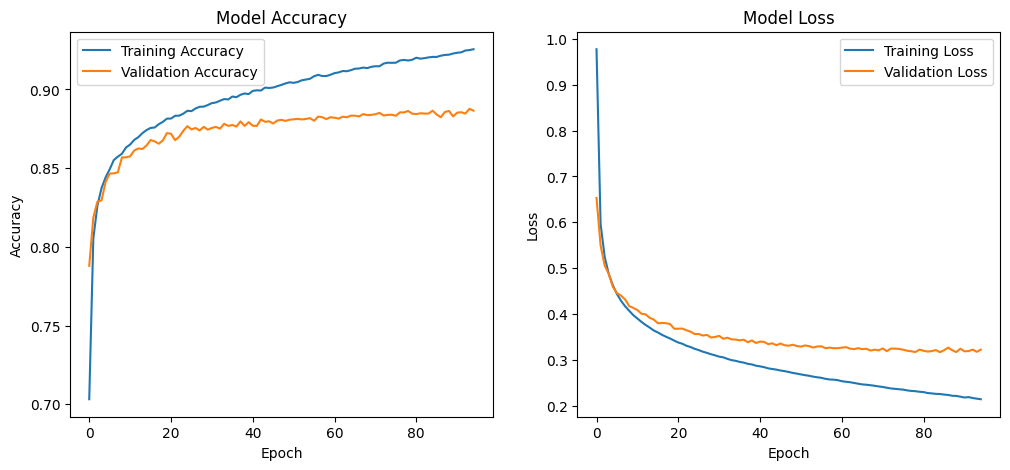

Test Accuracy: 88.19%
Test Loss: 0.3373


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [128]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# one hidden layer with 128 nodes and learning rate 0.001

Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7318 - loss: 0.7745 - val_accuracy: 0.8411 - val_loss: 0.4585
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8536 - loss: 0.4218 - val_accuracy: 0.8548 - val_loss: 0.4115
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8634 - loss: 0.3908 - val_accuracy: 0.8607 - val_loss: 0.3905
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8704 - loss: 0.3574 - val_accuracy: 0.8688 - val_loss: 0.3681
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8790 - loss: 0.3371 - val_accuracy: 0.8684 - val_loss: 0.3728
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8855 - loss: 0.3206 - val_accuracy: 0.8701 - val_loss: 0.3594
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8926 - loss: 0.2973 - val_accuracy: 0.8768 - val_loss: 0.3468
Epoch 8/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8976 - loss: 0.2843 - val_accu

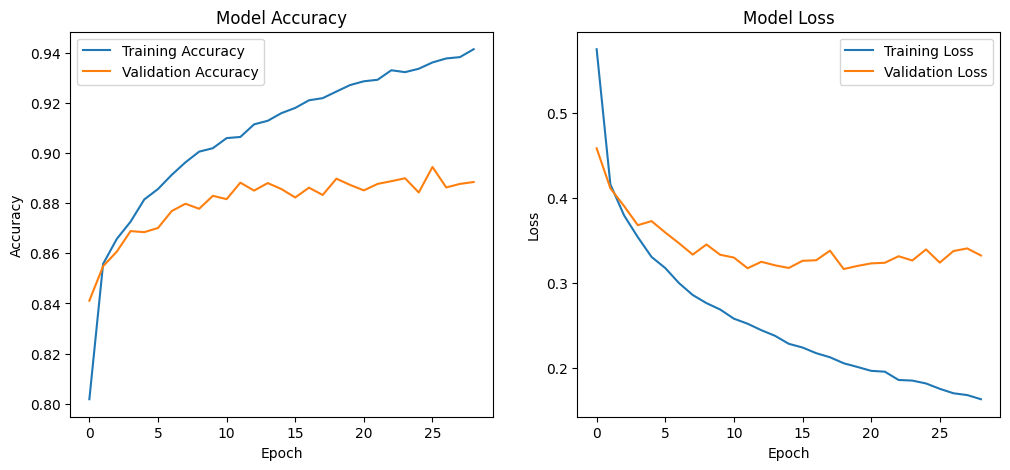

Test Accuracy: 88.16%
Test Loss: 0.3399


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [128]
learning_rate = 0.001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# one hidden layer 64 nodes 0.0001 learning rate

Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4979 - loss: 1.5271 - val_accuracy: 0.7643 - val_loss: 0.7541
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7759 - loss: 0.7041 - val_accuracy: 0.8012 - val_loss: 0.6048
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8074 - loss: 0.5839 - val_accuracy: 0.8160 - val_loss: 0.5456
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8186 - loss: 0.5365 - val_accuracy: 0.8262 - val_loss: 0.5113
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8337 - loss: 0.5021 - val_accuracy: 0.8348 - val_loss: 0.4889
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8390 - loss: 0.4811 - val_accuracy: 0.8354 - val_loss: 0.4748
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8452 - loss: 0.4625 - val_accuracy: 0.8417 - val_loss: 0.4603
Epoch 8/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8485 - loss: 0.4487 - val_accu

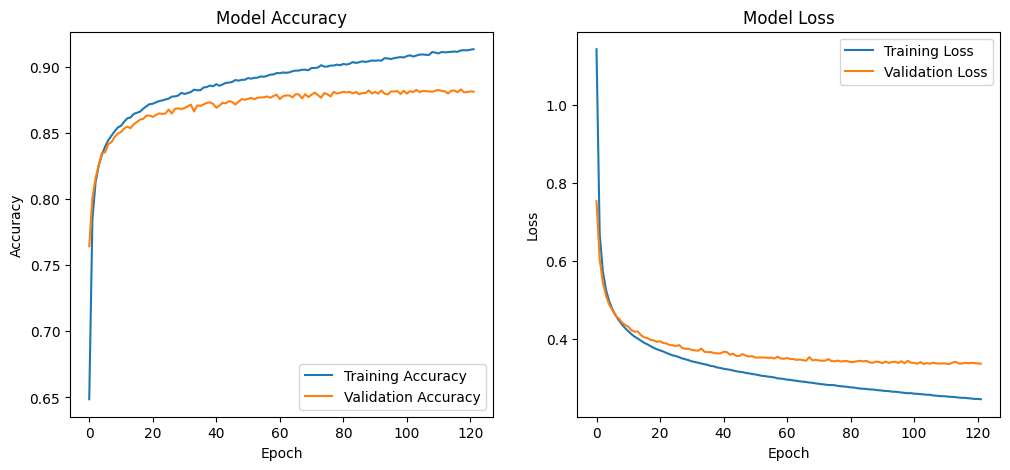

Test Accuracy: 87.52%
Test Loss: 0.3595


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [64]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# one hidden layer with 50 nodes and learning rate 0.00001

Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1911 - loss: 2.2738 - val_accuracy: 0.5151 - val_loss: 1.8950
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5420 - loss: 1.7930 - val_accuracy: 0.5993 - val_loss: 1.5213
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6078 - loss: 1.4609 - val_accuracy: 0.6430 - val_loss: 1.2915
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6403 - loss: 1.2605 - val_accuracy: 0.6651 - val_loss: 1.1297
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6625 - loss: 1.1096 - val_accuracy: 0.6808 - val_loss: 1.0233
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6738 - loss: 1.0184 - val_accuracy: 0.6952 - val_loss: 0.9482
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6914 - loss: 0.9419 - val_accuracy: 0.7082 - val_loss: 0.8909
Epoch 8/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7092 - loss: 0.8864 - val_accu

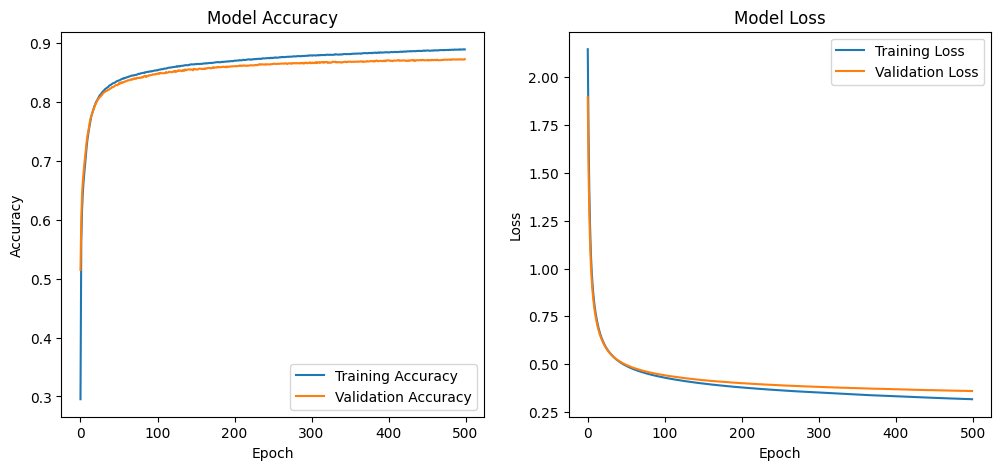

Test Accuracy: 86.66%
Test Loss: 0.3868


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [50]
learning_rate = 0.00001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


# Choosing the best models:
The model are chodesn between the models which were not showing overfitting signs

- 4 hidden layers model with best results
  - neurons: 32→32→16→16 and learning rate = 0.0001
    - accuracy = 86.87%
    - loss = 0.3781
- 3 hidden layers model with best results
  - neurons: 32→16→8 and learning rate = 0.001
    - accuracy = 87.00%
    - loss = 0.4047
- 2 hiddein layer model with best results
  - neurons: 32→16 and learning rate = 0.001
    - accuracy = 87.11%
    - loss = 0.3686
- 1 hidden layer model with best results
  - neurons: 128 and learing rate = 0.0001
    - accuracy = 88.19%
    - loss = 0.3373



# Plotting confusion matrix for the best model with 4 hidden layer


Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2798 - loss: 2.0544 - val_accuracy: 0.6445 - val_loss: 1.2380
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6527 - loss: 1.0809 - val_accuracy: 0.6941 - val_loss: 0.8101
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7043 - loss: 0.7777 - val_accuracy: 0.7342 - val_loss: 0.6994
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7470 - loss: 0.6867 - val_accuracy: 0.7744 - val_loss: 0.6305
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7853 - loss: 0.6156 - val_accuracy: 0.7990 - val_loss: 0.5723
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8057 - loss: 0.5591 - val_accuracy: 0.8124 - val_loss: 0.5301
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8176 - loss: 0.5223 - val_accuracy: 0.8217 - val_loss: 0.5083
Epoch 8/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8283 - loss: 0.4935 - val_accu

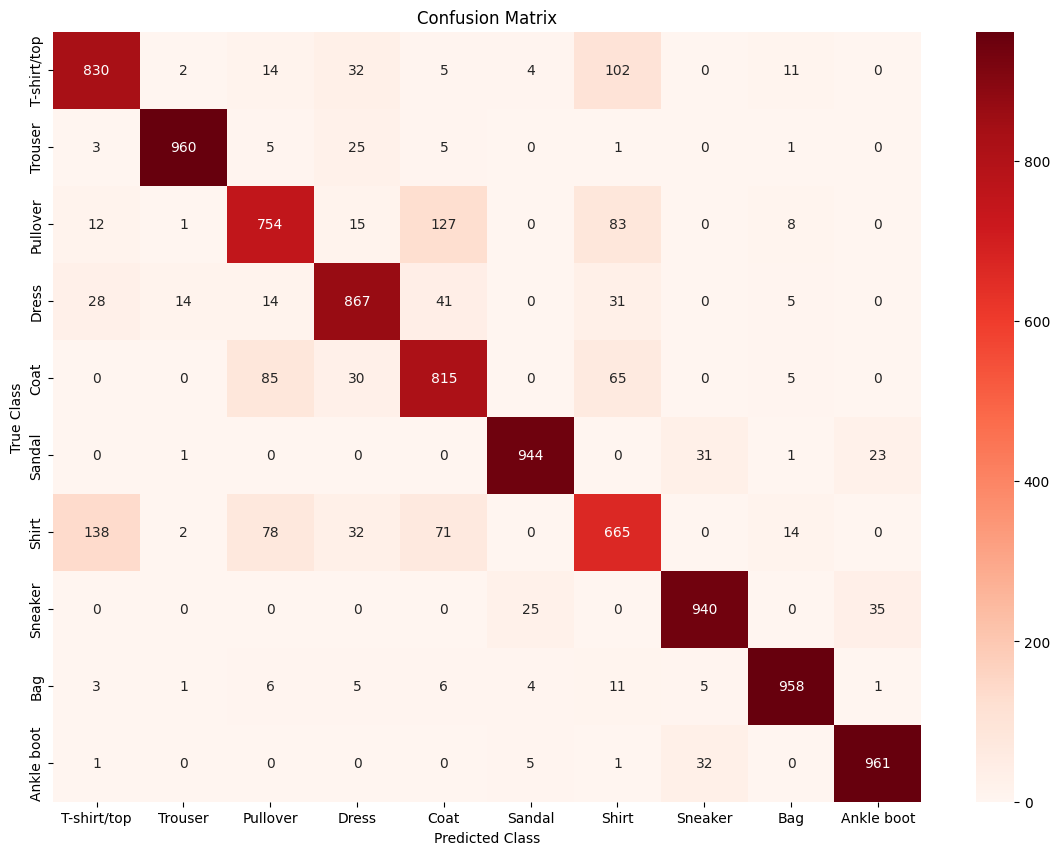

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.83      0.82      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.79      0.75      0.77      1000
       Dress       0.86      0.87      0.86      1000
        Coat       0.76      0.81      0.79      1000
      Sandal       0.96      0.94      0.95      1000
       Shirt       0.69      0.67      0.68      1000
     Sneaker       0.93      0.94      0.94      1000
         Bag       0.96      0.96      0.96      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Class 'T-shirt/top' has 170 misclassifications.
Class 'Trouser' has 40 misclassifications.
Class 'Pullover' has 246 misclassifications.
Class 'Dress' has 133 misclassifications.
Class 'Coat' has 185 misclassifications.
Class 'Sandal' has 56 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [32,32,16,16]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Class names for Fashion MNIST
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

# confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(14, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# most misclassified classes
misclassified_counts = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
for i, count in enumerate(misclassified_counts):
    print(f"Class '{class_names[i]}' has {count} misclassifications.")

# Plotting the confusion matrix for the best model with 3 hidden layers

Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5957 - loss: 1.1732 - val_accuracy: 0.8164 - val_loss: 0.5222
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8272 - loss: 0.4939 - val_accuracy: 0.8382 - val_loss: 0.4665
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8421 - loss: 0.4445 - val_accuracy: 0.8438 - val_loss: 0.4305
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8537 - loss: 0.4142 - val_accuracy: 0.8567 - val_loss: 0.4070
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8602 - loss: 0.3909 - val_accuracy: 0.8592 - val_loss: 0.4009
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8669 - loss: 0.3776 - val_accuracy: 0.8657 - val_loss: 0.3870
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8706 - loss: 0.3637 - val_accuracy: 0.8673 - val_loss: 0.3821
Epoch 8/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8731 - loss: 0.3571 - val_accu

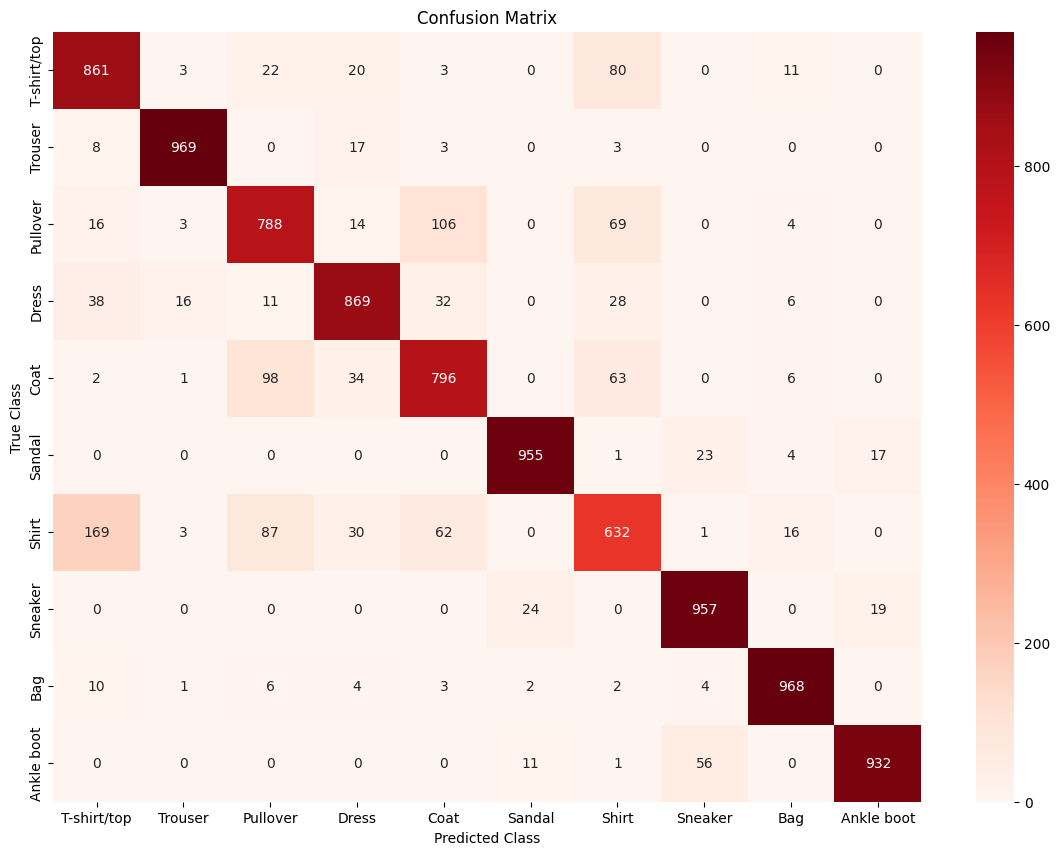

              precision    recall  f1-score   support

 T-shirt/top       0.78      0.86      0.82      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.78      0.79      0.78      1000
       Dress       0.88      0.87      0.87      1000
        Coat       0.79      0.80      0.79      1000
      Sandal       0.96      0.95      0.96      1000
       Shirt       0.72      0.63      0.67      1000
     Sneaker       0.92      0.96      0.94      1000
         Bag       0.95      0.97      0.96      1000
  Ankle boot       0.96      0.93      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Class 'T-shirt/top' has 139 misclassifications.
Class 'Trouser' has 31 misclassifications.
Class 'Pullover' has 212 misclassifications.
Class 'Dress' has 131 misclassifications.
Class 'Coat' has 204 misclassifications.
Class 'Sandal' has 45 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [32,16,8]
learning_rate = 0.001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Class names for Fashion MNIST
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

# confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(14, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# most misclassified classes
misclassified_counts = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
for i, count in enumerate(misclassified_counts):
    print(f"Class '{class_names[i]}' has {count} misclassifications.")

# Plotting the confusion matrix for the best model with two hidden layer

Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5613 - loss: 1.2359 - val_accuracy: 0.8261 - val_loss: 0.5218
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8340 - loss: 0.4888 - val_accuracy: 0.8361 - val_loss: 0.4686
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8514 - loss: 0.4356 - val_accuracy: 0.8516 - val_loss: 0.4283
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8604 - loss: 0.4056 - val_accuracy: 0.8539 - val_loss: 0.4122
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8648 - loss: 0.3839 - val_accuracy: 0.8616 - val_loss: 0.4026
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8737 - loss: 0.3686 - val_accuracy: 0.8607 - val_loss: 0.3961
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8735 - loss: 0.3656 - val_accuracy: 0.8676 - val_loss: 0.3842
Epoch 8/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8771 - loss: 0.3506 - val_acc

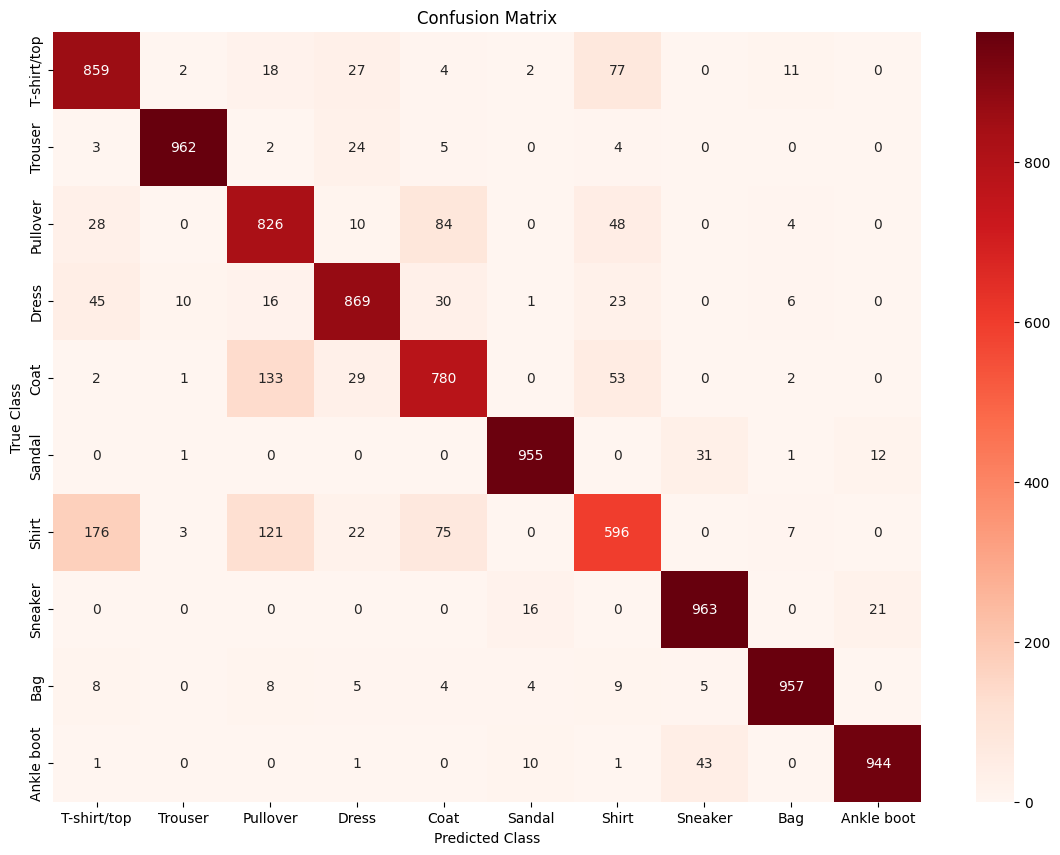

              precision    recall  f1-score   support

 T-shirt/top       0.77      0.86      0.81      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.73      0.83      0.78      1000
       Dress       0.88      0.87      0.87      1000
        Coat       0.79      0.78      0.79      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.73      0.60      0.66      1000
     Sneaker       0.92      0.96      0.94      1000
         Bag       0.97      0.96      0.96      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Class 'T-shirt/top' has 141 misclassifications.
Class 'Trouser' has 38 misclassifications.
Class 'Pullover' has 174 misclassifications.
Class 'Dress' has 131 misclassifications.
Class 'Coat' has 220 misclassifications.
Class 'Sandal' has 45 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [32,16]
learning_rate = 0.001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Class names for Fashion MNIST
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

# confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(14, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# most misclassified classes
misclassified_counts = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
for i, count in enumerate(misclassified_counts):
    print(f"Class '{class_names[i]}' has {count} misclassifications.")

# plotting the confusion matrix for the best model with 1 hidden layer

Epoch 1/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5644 - loss: 1.4067 - val_accuracy: 0.7774 - val_loss: 0.6847
Epoch 2/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7925 - loss: 0.6478 - val_accuracy: 0.8167 - val_loss: 0.5640
Epoch 3/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8226 - loss: 0.5478 - val_accuracy: 0.8283 - val_loss: 0.5168
Epoch 4/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8327 - loss: 0.5065 - val_accuracy: 0.8378 - val_loss: 0.4848
Epoch 5/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8385 - loss: 0.4785 - val_accuracy: 0.8404 - val_loss: 0.4677
Epoch 6/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8490 - loss: 0.4512 - val_accuracy: 0.8482 - val_loss: 0.4495
Epoch 7/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8547 - loss: 0.4350 - val_accuracy: 0.8518 - val_loss: 0.4367
Epoch 8/500
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8584 - loss: 0.4196 - val_accu

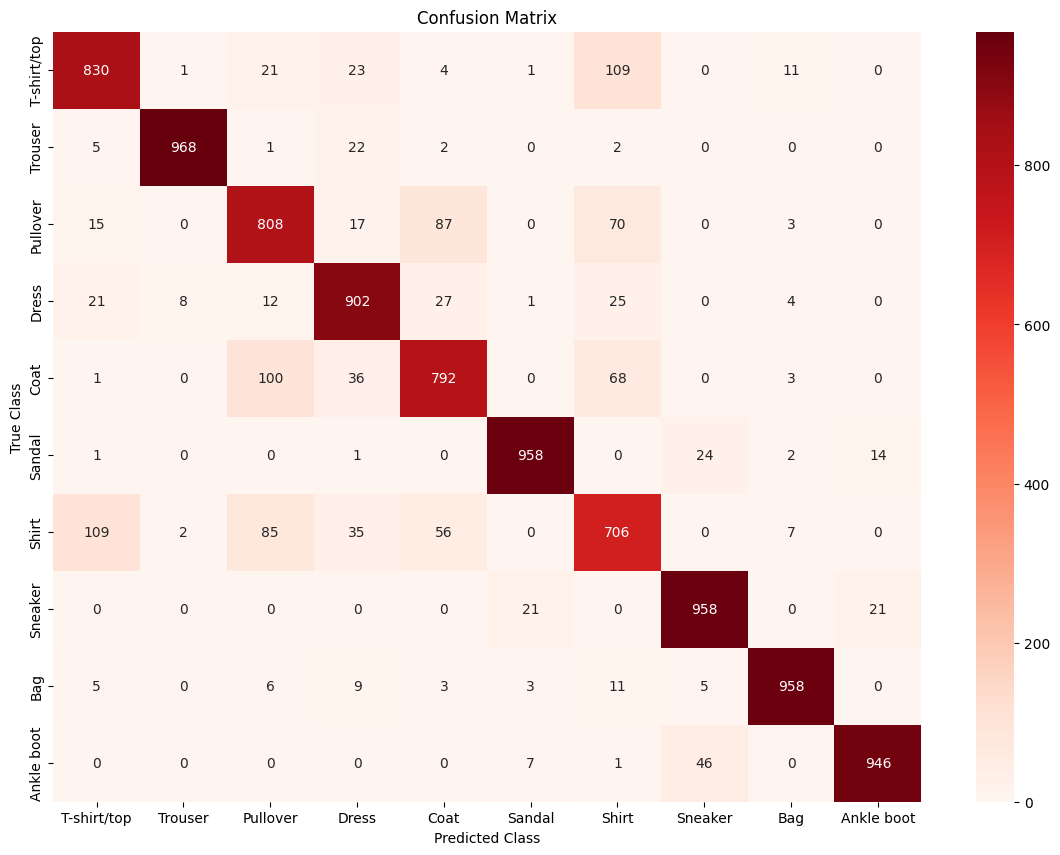

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.83      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.81      0.79      1000
       Dress       0.86      0.90      0.88      1000
        Coat       0.82      0.79      0.80      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.71      0.71      0.71      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.97      0.96      0.96      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Class 'T-shirt/top' has 170 misclassifications.
Class 'Trouser' has 32 misclassifications.
Class 'Pullover' has 192 misclassifications.
Class 'Dress' has 98 misclassifications.
Class 'Coat' has 208 misclassifications.
Class 'Sandal' has 42 m

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

hidden_layers = [128]
learning_rate = 0.0001
model = create_model(hidden_layers=hidden_layers, num_classes=10, learning_rate=learning_rate)

# early stop
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(X_train, y_train, epochs=500, batch_size=128, validation_split=0.2, callbacks=[early_stop])

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Class names for Fashion MNIST
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

# confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(14, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()

# classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# most misclassified classes
misclassified_counts = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
for i, count in enumerate(misclassified_counts):
    print(f"Class '{class_names[i]}' has {count} misclassifications.")